## Reducing Portfolio Risk by Diversification

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [7]:
df = pd.read_csv('../data/10stocks_price.csv')
df['date_gsheets'] = pd.to_datetime(df['date_gsheets'], format='mixed')
df.set_index('date_gsheets', inplace=True)

In [8]:
returns = df.pct_change(1)
returns.dropna(inplace=True)

In [9]:
num_stocks = 10
weights = [1 / num_stocks] * num_stocks
vcv_matrix = returns.cov(ddof=1)

var_p = np.dot(np.transpose(weights),
               np.dot(vcv_matrix, weights))
sd_p = np.sqrt(var_p)
sd_p_annual = sd_p * np.sqrt(250)

individual_risks = returns.std(ddof=1) * np.sqrt(250)

We are going to create 10 separate portfolios of these 10 stocks

In [10]:
returns.head()

,AAPL,KO,NFLX,BRK.B,DIS,IBM,VZ,WMT,GE,TSLA
date_gsheets,,,,,,,,,,
2012-01-04 16:00:00,0.005277,-0.006273,0.113372,-0.011329,0.014096,-0.004079,-0.013088,-0.010277,0.010893,-0.013177
2012-01-05 16:00:00,0.011175,-0.004591,-0.013925,0.001693,0.016731,-0.004743,-0.006886,-0.004857,-0.000539,-0.021292
2012-01-06 16:00:00,0.010382,-0.006342,0.088261,-0.007019,0.010380,-0.011481,-0.015665,-0.007068,0.005391,-0.007743
2012-01-09 16:00:00,-0.001492,0.000000,0.137875,-0.001309,-0.004009,-0.005204,0.001044,0.003051,0.011260,0.012635
2012-01-10 16:00:00,0.003485,0.005802,-0.024234,0.014812,-0.003019,-0.001542,0.005212,-0.002366,-0.007423,0.013578


In [16]:
tickers = list(returns.columns)

In [19]:
portfolios = []

for i in range(1, len(tickers) + 1):
    portfolios.append(tickers[0:i])


In [20]:
portfolios

[['AAPL'],
 ['AAPL', 'KO'],
 ['AAPL', 'KO', 'NFLX'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ', 'WMT'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ', 'WMT', 'GE'],
 ['AAPL', 'KO', 'NFLX', 'BRK.B', 'DIS', 'IBM', 'VZ', 'WMT', 'GE', 'TSLA']]

In [21]:
# calculate the risk of each portfolio
portfolio_risks = []
for port in portfolios:
    df = returns[port]
    
    num_stocks = len(df.columns)
    weights = [1 / num_stocks] * num_stocks
    vcv_p = df.cov(ddof=1)

    var_p = np.dot(np.transpose(weights),
                  np.dot(vcv_p, weights))
    sd_p = np.sqrt(var_p)
    sd_p_annual = sd_p * np.sqrt(250)

    portfolio_risks.append(sd_p_annual)

In [22]:
portfolio_risks

[np.float64(0.2480850537556883),
 np.float64(0.15361677406524374),
 np.float64(0.2114565541739028),
 np.float64(0.17491660730394215),
 np.float64(0.15759159863421654),
 np.float64(0.1457126656138722),
 np.float64(0.1342292929262248),
 np.float64(0.12628134430343538),
 np.float64(0.12416648815658814),
 np.float64(0.13539455221149155)]

In [23]:
risks_df = pd.DataFrame(portfolio_risks)

In [24]:
risks_df.rename(columns={risks_df.columns[0] : 'total risk'},
               inplace=True)

In [25]:
risks_df

,total risk
0,0.248085
1,0.153617
2,0.211457
3,0.174917
4,0.157592
5,0.145713
6,0.134229
7,0.126281
8,0.124166
9,0.135395


<Axes: >

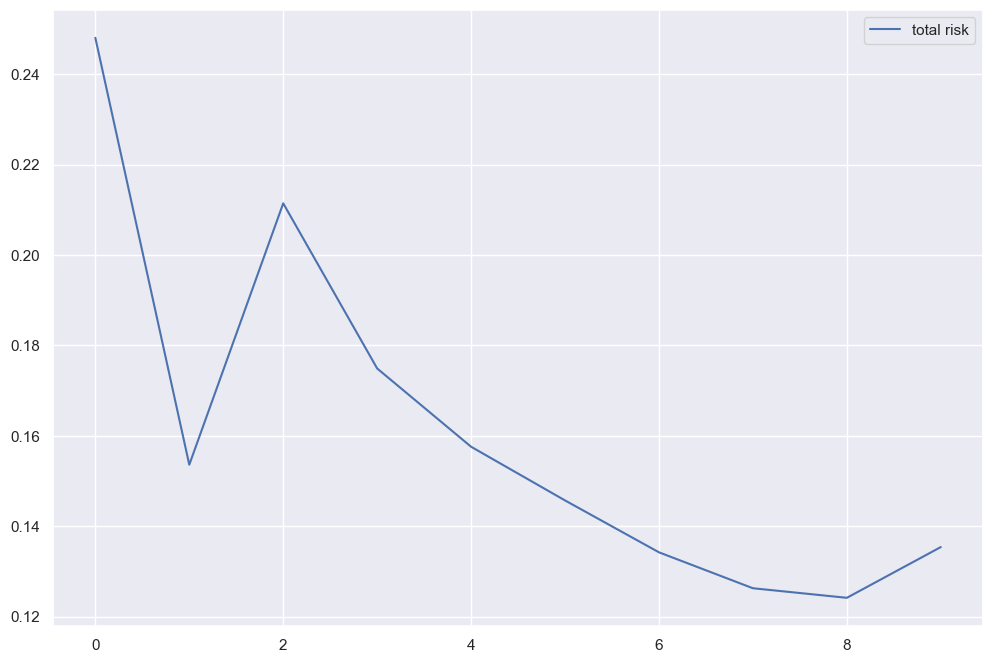

In [26]:
risks_df.plot(figsize=(12,8))

In [28]:
returns.std() * np.sqrt(250)

AAPL     0.248085
KO       0.137303
NFLX     0.515473
BRK.B    0.141077
DIS      0.181373
IBM      0.181766
VZ       0.160274
WMT      0.169337
GE       0.184540
TSLA     0.482390
dtype: float64